# Sparse Latent Dynamics via SINDy

This notebook uses `identify_sparse_dynamics` to fit a **sparse library**
(STLSQ) to a model's **encoded** trajectories, prints a recovered-term table,
and contrasts (1) a planted latent map where coefficients are ground truth
with (2) a fitted epidemic-ring model where terms describe the *learned*
latent, not SIR ODEs.

**Caveat (read first):** SINDy here diagnoses the latent map. It does **not**
recover physical governing equations in the original node features
(Brunton, Proctor & Kutz, *PNAS* 2016 — `Brunton2016SINDy`). Contrast the
training-time sparse *operator* penalty in
[`26_sparse_interpretable_operator.ipynb`](26_sparse_interpretable_operator.ipynb).


## Setup


In [1]:
import warnings

from tqdm.std import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)

import os
import random

import matplotlib

if os.environ.get("PYTEST_CURRENT_TEST") or os.environ.get("CI"):
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch_geometric.data import Data

import koopman_graph
from koopman_graph import GNNDecoder, GNNEncoder, GraphKoopmanModel
from koopman_graph.analysis import identify_sparse_dynamics
from koopman_graph.data import GraphSnapshotSequence
from koopman_graph.datasets import EpidemicNetworkBenchmark

IS_TEST = bool(
    os.environ.get("PYTEST_CURRENT_TEST")
    or os.environ.get("CI")
    or os.environ.get("IS_TEST")
)
SEED = 32
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

EPOCHS = 2 if IS_TEST else 40
N_NODES = 8 if IS_TEST else 16
N_STEPS = 24 if IS_TEST else 48
print(
    f"koopman_graph={koopman_graph.__version__}  "
    f"IS_TEST={IS_TEST}  EPOCHS={EPOCHS}  N_NODES={N_NODES}"
)


koopman_graph=0.5.0  IS_TEST=False  EPOCHS=40  N_NODES=16


## Motivation and background

Sparse identification of nonlinear dynamics (SINDy) builds a candidate library
$\Theta(z)$ (polynomials, optionally graph-Laplacian features) and solves a
thresholded least-squares problem for $\Xi$ so that
$z_{t+1} \approx \Theta(z_t)\,\Xi$ (discrete) or
$\dot{z} \approx \Theta(z)\,\Xi$ (continuous / finite-difference).

This notebook uses `mode="discrete"`. In term tables and plots, the label
`z_j'` means the **next-step** latent channel (the $z_{t+1}$ target), not a
time derivative. Continuous mode would label channels `dz_j/dt` instead.

In KoopmanGraph this is a **post-hoc diagnostic** on encoded latents
(`koopman_graph.analysis.identify_sparse_dynamics`). Related but distinct:
notebook 26 sparsifies the *Koopman matrix* during training. Temporal-GNN /
Koopman interpretation appears in Guerra et al. (2024) — `Guerra2024`.


## Helpers: planted map, term table, identity encode


In [2]:
def path_edge_index(num_nodes: int) -> torch.Tensor:
    edges: list[list[int]] = []
    for node in range(num_nodes - 1):
        edges.extend([[node, node + 1], [node + 1, node]])
    return torch.tensor(edges, dtype=torch.long).t().contiguous()


def identity_latent_model(latent_dim: int = 2) -> GraphKoopmanModel:
    model = GraphKoopmanModel(
        encoder=GNNEncoder(latent_dim, 4, latent_dim, num_layers=1),
        decoder=GNNDecoder(latent_dim, 4, latent_dim, num_layers=1),
        latent_dim=latent_dim,
        time_step=0.1,
    )

    def _encode(x_or_data, edge_index=None, edge_weight=None):
        del edge_index, edge_weight
        if isinstance(x_or_data, Data):
            assert x_or_data.x is not None
            return x_or_data.x
        return x_or_data

    model.encode = _encode  # type: ignore[method-assign]
    return model


def planted_discrete_sequence(
    *,
    num_nodes: int = 4,
    num_timesteps: int = 40,
    seed: int = 0,
) -> GraphSnapshotSequence:
    """Noiseless trajectory: z0' = 0.8 z0 + 0.15 z0^2 ; z1' = 0.7 z1."""
    torch.manual_seed(seed)
    edge_index = path_edge_index(num_nodes)
    z = 0.3 * torch.randn(num_nodes, 2)
    snapshots: list[Data] = [Data(x=z.clone(), edge_index=edge_index)]
    for _ in range(num_timesteps - 1):
        z_next = torch.empty_like(z)
        z_next[:, 0] = 0.8 * z[:, 0] + 0.15 * z[:, 0] ** 2
        z_next[:, 1] = 0.7 * z[:, 1]
        z = z_next
        snapshots.append(Data(x=z.clone(), edge_index=edge_index))
    return GraphSnapshotSequence(snapshots)


def report_to_frame(report) -> pd.DataFrame:
    """Active terms only — one row per (term, latent output channel)."""
    rows = []
    coef = report.coefficients.detach().cpu().numpy()
    mask = report.active_mask.detach().cpu().numpy()
    for i, name in enumerate(report.term_names):
        for j in range(coef.shape[1]):
            if mask[i, j]:
                rows.append(
                    {
                        "term": name,
                        "output": f"z{j}'" if report.mode == "discrete" else f"dz{j}/dt",
                        "coefficient": float(coef[i, j]),
                    }
                )
    return pd.DataFrame(rows).sort_values(
        ["output", "term"], ignore_index=True
    )


## Minimal example: recover a planted sparse map

When encode is the identity, SINDy should recover the known discrete map
(within STLSQ tolerance). Table columns labeled `z0'` / `z1'` are next-step
targets under `mode="discrete"`. This is the sanity check before any
*learned*-latent run.


In [3]:
planted = planted_discrete_sequence(
    num_nodes=4, num_timesteps=40 if not IS_TEST else 24, seed=SEED
)
id_model = identity_latent_model(2)
planted_report = identify_sparse_dynamics(
    id_model,
    planted,
    library="poly",
    degree=2,
    threshold=0.05,
    mode="discrete",
)
planted_table = report_to_frame(planted_report)
print(f"library={planted_report.library}  mode={planted_report.mode}")
print(f"residual (MSE)={planted_report.residual:.2e}")
print(f"STLSQ thresholds: {planted_report.threshold_history}")
print("Active terms (planted / identity encode):")
print(planted_table.to_string(index=False))

# Spot-check against ground truth.
names = list(planted_report.term_names)
i_z0, i_z0sq, i_z1 = names.index("z0"), names.index("z0^2"), names.index("z1")
c = planted_report.coefficients
print(
    f"expected z0'≈0.8 z0 + 0.15 z0^2 → got "
    f"{c[i_z0, 0].item():.3f} z0 + {c[i_z0sq, 0].item():.3f} z0^2"
)
print(f"expected z1'≈0.7 z1 → got {c[i_z1, 1].item():.3f} z1")


library=poly  mode=discrete
residual (MSE)=4.76e-17
STLSQ thresholds: (0.05, 0.05)
Active terms (planted / identity encode):
term output  coefficient
  z0    z0'         0.80
z0^2    z0'         0.15
  z1    z1'         0.70
expected z0'≈0.8 z0 + 0.15 z0^2 → got 0.800 z0 + 0.150 z0^2
expected z1'≈0.7 z1 → got 0.700 z1


## Progressive deep dive: fitted epidemic ring (learned latents)

Fit a small Koopman model on networked SIR, then run SINDy on **encoded**
states. Active terms describe the latent coordinates — **not** $\beta SI$ /
recovery terms in $(S,I,R)$. On a short fit the recovered library is often
*dense* (many active terms, large coefficients); treat that as a diagnostic
fingerprint of the encoder, not as sparse governing equations.


In [4]:
torch.manual_seed(SEED)
epidemic = EpidemicNetworkBenchmark.generate(
    num_nodes=N_NODES,
    num_timesteps=N_STEPS,
    topology="ring",
    seed=SEED,
)
# Use infected fraction as scalar feature for a compact latent.
inf_seq = GraphSnapshotSequence(
    [Data(x=snap.x[:, 1:2], edge_index=snap.edge_index) for snap in epidemic]
)
latent_dim = 2 if IS_TEST else 4
torch.manual_seed(SEED)
epi_model = GraphKoopmanModel(
    encoder=GNNEncoder(1, 16, latent_dim, num_layers=2),
    decoder=GNNDecoder(latent_dim, 16, 1, num_layers=2),
    latent_dim=latent_dim,
    time_step=1.0,
)
_ = epi_model.fit(inf_seq, epochs=EPOCHS, lr=1e-3)
print(f"epidemic fit done  latent_dim={latent_dim}  T={inf_seq.num_timesteps}")


epidemic fit done  latent_dim=4  T=48


Run SINDy on the fitted encoder. Print residual in scientific notation and the
active-coefficient fraction so a near-zero MSE is not mistaken for a sparse
physical recovery.

In [5]:
# Threshold: slightly higher under short CI fits (noisier latents).
epi_threshold = 0.15 if IS_TEST else 0.08
epi_report = identify_sparse_dynamics(
    epi_model,
    inf_seq,
    library="poly",
    degree=2,
    threshold=epi_threshold,
    mode="discrete",
)
epi_table = report_to_frame(epi_report)
n_coef = int(epi_report.coefficients.numel())
n_active = int(epi_report.active_mask.sum())
coef_abs_max = float(epi_report.coefficients.abs().max())
print(
    f"epidemic latent SINDy  residual(MSE)={epi_report.residual:.2e}  "
    f"n_active={n_active}/{n_coef}  "
    f"(|Ξ|_max={coef_abs_max:.2f}, threshold={epi_threshold})"
)
print(
    "WARNING: these terms are in learned latent coordinates z — "
    "do not read them as SIR reaction rates. "
    f"Active fraction {n_active / n_coef:.0%} is often dense on short fits."
)
print(epi_table.to_string(index=False))

# Optional graph library (Laplacian-augmented) for contrast.
graph_report = identify_sparse_dynamics(
    epi_model,
    inf_seq,
    library="graph",
    degree=1,
    threshold=0.25 if IS_TEST else 0.12,
    mode="discrete",
)
n_lsym = sum(1 for n in graph_report.term_names if n.startswith("Lsym:"))
n_g_coef = int(graph_report.coefficients.numel())
n_g_active = int(graph_report.active_mask.sum())
print(
    f"graph library: {len(graph_report.term_names)} terms "
    f"({n_lsym} Lsym:*)  residual(MSE)={graph_report.residual:.2e}  "
    f"n_active={n_g_active}/{n_g_coef}"
)


epidemic latent SINDy  residual(MSE)=4.05e-05  n_active=40/60  (|Ξ|_max=110.42, threshold=0.08)
 term output  coefficient
   z0    z0'     4.403502
z0*z1    z0'   -14.325913
z0*z3    z0'   -21.183998
 z0^2    z0'    45.867310
   z1    z0'    -0.927599
z1*z3    z0'     0.621014
   z2    z0'     2.188904
 z3^2    z0'     4.129343
   z0    z1'    10.858566
z0*z1    z1'   -12.134481
z0*z2    z1'    19.557262
z0*z3    z1'    23.185150
 z0^2    z1'    58.427475
   z1    z1'     5.095203
z1*z3    z1'   -54.958179
   z2    z1'    19.543142
z2*z3    z1'   110.419441
 z3^2    z1'    57.665825
   z0    z2'    -0.414908
z0*z1    z2'    -2.796433
z0*z2    z2'     3.796386
z0*z3    z2'    -6.546594
 z0^2    z2'    -6.169261
   z1    z2'     2.562735
   z2    z2'     0.985511
 z2^2    z2'    -1.952101
   z3    z2'    -2.132495
 z3^2    z2'     2.471490
   z0    z3'    -0.161990
z0*z1    z3'     6.872460
z0*z2    z3'    -9.169390
z0*z3    z3'    15.998520
 z0^2    z3'    14.922035
   z1    z3'    -7.8

## Results

Coefficient heatmap of the planted recovery (identity encode) vs active-term
counts on the epidemic latent fit. Look for sparse structure in the planted
panel. The epidemic panel typically shows many active terms per channel — a
diagnostic fingerprint of the learned latent, not a sparse physical model.
Print residuals in scientific notation so a small MSE is not read as exact zero.

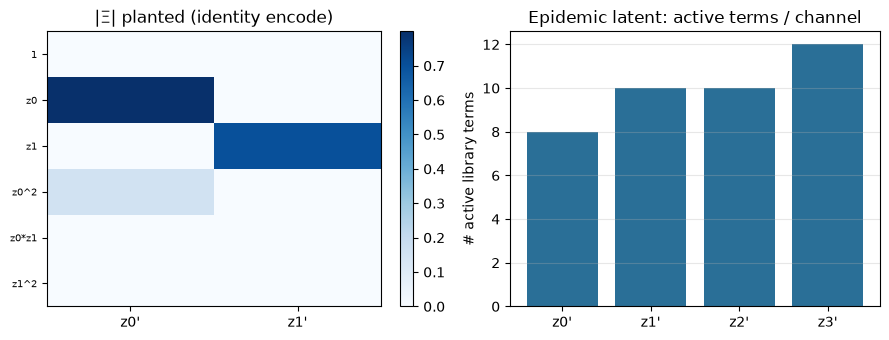

planted residual(MSE)=4.76e-17  epidemic residual(MSE)=4.05e-05  epidemic active=40/60


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

planted_coef = planted_report.coefficients.detach().cpu().numpy()
im0 = axes[0].imshow(np.abs(planted_coef), aspect="auto", cmap="Blues")
axes[0].set_yticks(range(len(planted_report.term_names)))
axes[0].set_yticklabels(planted_report.term_names, fontsize=7)
axes[0].set_xticks(range(planted_coef.shape[1]))
axes[0].set_xticklabels([f"z{j}'" for j in range(planted_coef.shape[1])])
axes[0].set_title(r"$|\Xi|$ planted (identity encode)")
fig.colorbar(im0, ax=axes[0], fraction=0.046)

# Active counts per output for epidemic
active = epi_report.active_mask.detach().cpu().numpy()
counts = active.sum(axis=0)
axes[1].bar(
    [f"z{j}'" for j in range(len(counts))],
    counts,
    color="#2a6f97",
)
axes[1].set_ylabel("# active library terms")
axes[1].set_title("Epidemic latent: active terms / channel")
axes[1].grid(axis="y", alpha=0.3)
fig.tight_layout()
with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        message="FigureCanvasAgg is non-interactive",
        category=UserWarning,
    )
    plt.show()

print(
    f"planted residual(MSE)={planted_report.residual:.2e}  "
    f"epidemic residual(MSE)={epi_report.residual:.2e}  "
    f"epidemic active={n_active}/{n_coef}"
)


## Interpretation

- **Planted / identity encode:** STLSQ recovers the quadratic map — evidence
  that the library + threshold machinery works when latents *are* the state.
- **Fitted epidemic:** Encoder coordinates are not $(S,I,R)$. A term like
  `z0^2` describes *latent* advance, not $\beta SI$. On this short fit the
  active set is typically dense (often well above half of the coefficient
  slots) with large $|\Xi|$ entries; a small residual MSE does **not** imply
  a sparse or physically meaningful recovery.
- Prefer notebook 26 when you want sparsity in $K$ itself during training;
  prefer SINDy here when you want a readable library expansion of encoded
  dynamics after the fact — and raise the threshold or shrink the library if
  you need a shorter term list for inspection.


## Takeaways

- Call `identify_sparse_dynamics(model, sequence, threshold=..., library=...)`
  after fit; inspect `SINDyReport` term tables and residual (prefer scientific
  notation for MSE).
- **When to use:** post-hoc library expansion of encoded dynamics; planted
  identity-encode checks when tuning thresholds.
- **When not to use:** reading latent terms as physical ODEs, or treating a
  dense high-$|\Xi|$ fit with small residual as governing-equation discovery.
- **Gotchas:** `z_j'` means discrete next-step under `mode="discrete"`; short
  epidemic / real-data fits are often dense — raise `threshold` or reduce
  `degree` / `latent_dim` before interpreting term lists.
- Cross-check with notebook 26 (sparse operator loss) for sparsity in $K$
  during training rather than in a post-hoc library.


## Further reading

- API: `koopman_graph.analysis.identify_sparse_dynamics`, `SINDyReport`
- Related notebook:
  [`26_sparse_interpretable_operator.ipynb`](26_sparse_interpretable_operator.ipynb)
- Citations (`paper.bib`): `Brunton2016SINDy`, `Guerra2024`
